#Importing Libraries

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

#Test set Image Processing

In [39]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'Dataset',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 35727 files belonging to 23 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


#Loading Model

In [40]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

#Performing Prediction on Single image

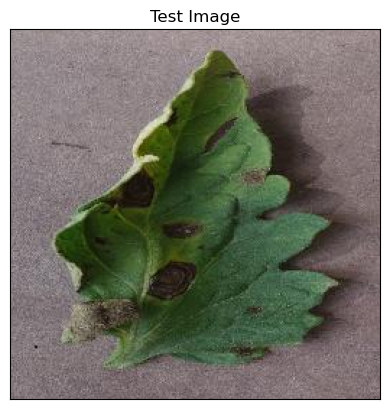

In [41]:
#Test Image Visualization
import cv2
image_path ='Dataset\Tomato_Early_blight\e3b74c49-7e82-4094-8a02-5ae7644a1d00___RS_Erly.B 7393.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

#Testing the Model

In [42]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


In [43]:
print(predictions)

[[2.18406370e-07 7.46155209e-08 8.10017468e-07 1.75563162e-06
  8.63058006e-07 1.40119267e-08 7.46502792e-07 3.16250470e-09
  1.38356345e-05 9.49759951e-08 7.39380539e-08 1.50750711e-04
  1.41557294e-07 3.08302976e-03 9.51315284e-01 2.99786567e-03
  5.77815401e-04 1.52081274e-03 3.64290038e-03 3.66734453e-02
  1.59486244e-05 4.23084629e-07 3.01972000e-06]]


In [44]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

14


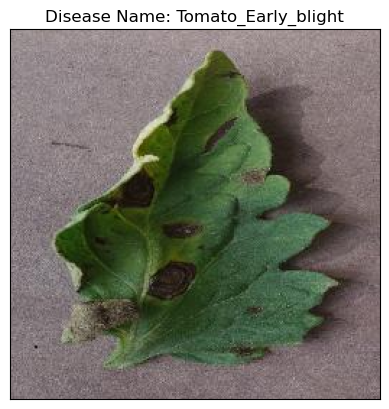

Confidence: 95.13153


In [45]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()
confidence = np.max(predictions) * 100
print("Confidence:", confidence)